# **🎧 ETL Pipeline – Spotify Tracks Dataset Project**

**Step 1 — Load the Dataset in Jupyter**

Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [3]:
df = pd.read_csv("/content/spotify_tracks.csv")

df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


**Step 2 — Basic Dataset Information**

In [21]:
df.shape

(114000, 23)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 23 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   Unnamed: 0        114000 non-null  int64   
 1   track_id          114000 non-null  object  
 2   artists           113999 non-null  object  
 3   album_name        113999 non-null  object  
 4   track_name        113999 non-null  object  
 5   popularity        114000 non-null  int64   
 6   duration_ms       114000 non-null  int64   
 7   explicit          114000 non-null  bool    
 8   danceability      114000 non-null  float64 
 9   energy            114000 non-null  float64 
 10  key               114000 non-null  int64   
 11  loudness          114000 non-null  float64 
 12  mode              114000 non-null  int64   
 13  speechiness       114000 non-null  float64 
 14  acousticness      114000 non-null  float64 
 15  instrumentalness  114000 non-null  float64 
 16  li

In [23]:
df.describe()


,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,duration_min
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035,3.800486
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621,1.788295
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000,2.901100
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000,3.548433
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000,4.358433
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000,87.288250


**Step 3 — Remove Unnecessary Column**

In [24]:
df = df.drop(columns=['Unnamed: 0'])

In [25]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min,popularity_level
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,3.844433,High
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,2.493500,Medium
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,3.513767,Medium
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,3.365550,High
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,3.314217,High


**Step 4 — Check Missing Values**

In [26]:
df.isnull().sum()

,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


**Step 5 — Remove Duplicate Songs**

In [27]:
df = df.drop_duplicates(subset=['track_id'])

**Step 6 — Feature Engineering**

Convert duration to minutes:

In [28]:
df['duration_min'] = df['duration_ms'] / 60000

Create popularity category:

In [29]:
df['popularity_level'] = pd.cut(
    df['popularity'],
    bins=[0,40,70,100],
    labels=['Low','Medium','High']
)

**Step 7 — Top 10 Most Popular Songs**

In [30]:
top_tracks = df[['track_name','artists','popularity']] \
                .sort_values(by='popularity', ascending=False) \
                .head(10)

top_tracks

,track_name,artists,popularity
20001,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100
51664,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,99
20008,I'm Good (Blue),David Guetta;Bebe Rexha,98
67356,La Bachata,Manuel Turizo,98
67358,Me Porto Bonito,Bad Bunny;Chencho Corleone,97
67359,Tití Me Preguntó,Bad Bunny,97
20000,Under The Influence,Chris Brown,96
79000,I Ain't Worried,OneRepublic,96
67559,Efecto,Bad Bunny,96
67500,Ojitos Lindos,Bad Bunny;Bomba Estéreo,95


**Step 8 — Genre Distribution**

In [31]:
df['track_genre'].value_counts().head(10)

,count
track_genre,
acoustic,1000
afrobeat,999
alt-rock,999
ambient,999
cantopop,999
tango,999
chicago-house,998
forro,998
bluegrass,998


Visualization:

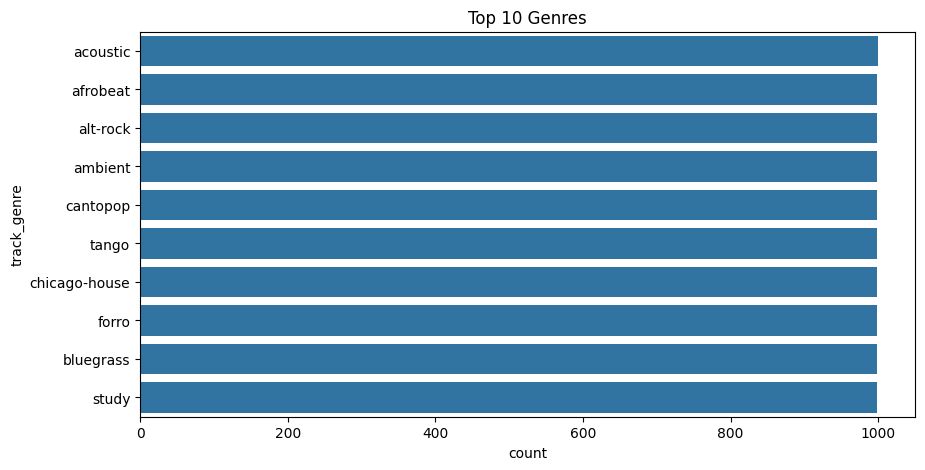

In [32]:
plt.figure(figsize=(10,5))

sns.countplot(
    y='track_genre',
    data=df,
    order=df['track_genre'].value_counts().index[:10]
)

plt.title("Top 10 Genres")
plt.show()

**Step 9 — Danceability vs Popularity**

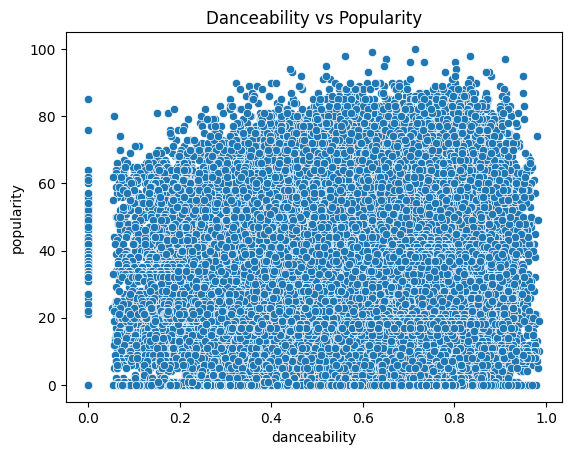

In [33]:
sns.scatterplot(x='danceability', y='popularity', data=df)

plt.title("Danceability vs Popularity")

plt.show()

**Step 10 — Correlation Between Audio Features**

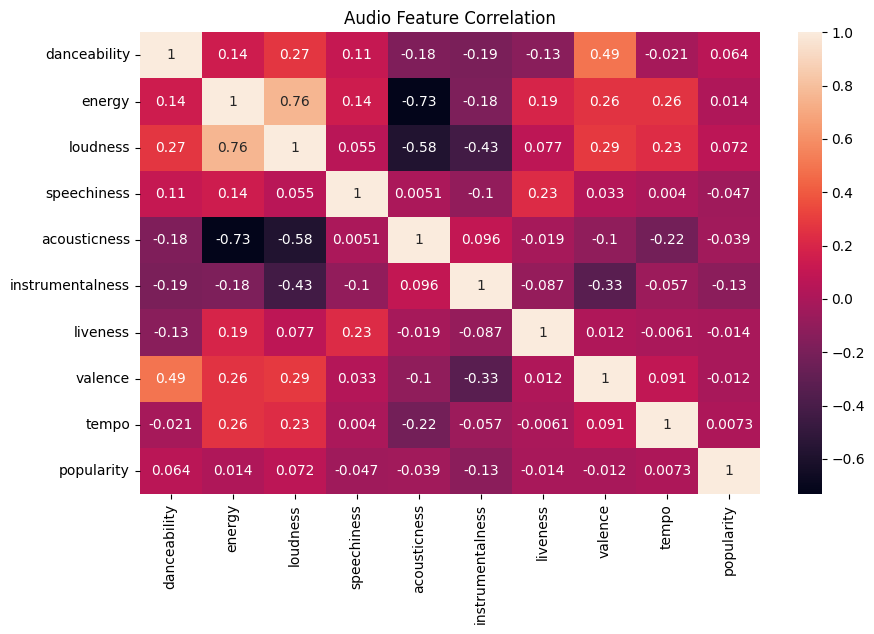

In [34]:
features = [
'danceability','energy','loudness',
'speechiness','acousticness',
'instrumentalness','liveness',
'valence','tempo','popularity'
]

corr = df[features].corr()

plt.figure(figsize=(10,6))

sns.heatmap(corr, annot=True)

plt.title("Audio Feature Correlation")

plt.show()

**Step 11 — Save Clean Dataset**

In [35]:
df.to_csv("spotify_cleaned.csv", index=False)